# Are We There Yet?

Author: Fred J. Hickernell

You are visiting your friend and it will require
* A $5$ minute walk to the ‘L’ station
* Waiting for the train, which arrives every $20$ minutes
* Traveling $30$ minutes by ‘L’
* Catching a taxi at the ‘L’ destination
  * There is a $20\%$ chance that the car is waiting for you
  * Otherwise the average wait time is 10 minutes
* A $12$ minute taxi ride 

_How long should you plan for the trip to take?_

#### Run this notebook in Juypter with the `conda qmcpy` environment or [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QMCSoftware/MATH565Fall2026/blob/main/notebooks/Applications/AreWeThereYet.ipynb?flush_cache=true)

In [1]:
if "google.colab" in str(get_ipython()):
    print("⚡Note: Setup here can take a few minutes.")
    !apt-get -y install cm-super dvipng texlive-latex-extra texlive-latex-recommended
    %pip install git+https://github.com/QMCSoftware/qmcpy.git@develop
    !git clone https://github.com/QMCSoftware/MATH565Fall2025.git
    %cd MATH565Fall2025/notebooks
    print("\n✅ Colab setup complete.")
    print("   For faster performance, please install the qmcpy environment locally.")

## Mathematical set-up
$$
\begin{aligned}
T & = \text{travel time} = 5 + W_1 + 30 + W_2 + 12 = 47 + W_1 + W_2 \\
W_1 & = \text{waiting time for 'L' train} \sim \mathcal{U}[0,20] \\
W_2 & = \text{waiting time for taxi}, \quad 
\mathbb{P} (W_2 \le w) = \begin{cases} 0, & w < 0 \\ 0.2+ 0.8 [1 - \exp(-w/10)], & w \ge 0 \end{cases}
\end{aligned}
$$

We assume that $W_1$ and $W_2$ are independent

We will now perform Monte Carlo simulation


### Input libraries

In [2]:
import numpy as np
import qmcpy as qp
import matplotlib.pyplot as plt
import scipy.stats as stats
from IPython.display import display, Markdown
import classlib as cl

%matplotlib inline

cl.nbviz.init(use_tex=True)
colors = cl.nbviz.TOL_BRIGHT

### Set up problem parameters

In [3]:
# We define these with variables so that we can change their values later
walk_time = 5  #time to walk to the 'L'  You can experiment by chaning these
on_L_time = 30  #time on the 'L'
taxi_time = 12  #time in the taxi
max_L_time = 20  #max time until next 'L' train
taxi_now = 0.2  #probability of taxi now
taxi_wait_avg = 10  #average time to wait for a taxi if it is not there

### Set up random vector $\boldsymbol{W} = (W_1,W_2)$

In [4]:
# We will do this using the qmcpy library since it has the zero-inflated exponential

# We construct the marginals using a dummy sampler
wait_L_marginal = qp.Uniform(qp.DummySampler(1), lower_bound=0.0, upper_bound=max_L_time)  # L wait time
wait_taxi_marginal = qp.ZeroInflatedExpUniform(qp.DummySampler(1), p_zero=taxi_now, lam=1/taxi_wait_avg)  # taxi wait time

# This is a two-dimensional random vector so we first make a 2-D sampler
dim = 2
IIDUniformSampler = qp.IIDStdUniform(dim)

#Now we transform the standard uniform into W = (W_1,W_2) with the desired distributions
WaitingTimeSampler = qp.ProductMeasure(sampler=IIDUniformSampler, marginals=[wait_L_marginal, wait_taxi_marginal])  #combine two marginals

### Sample and plot the waiting times

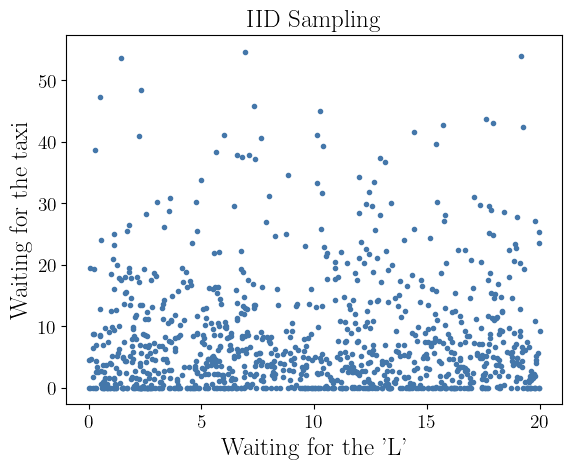

In [5]:
n = 2**10 #number of samples
Wait_samples=WaitingTimeSampler(n)  #generate samples

plt.plot(Wait_samples[:,0], Wait_samples[:,1],'.')
plt.xlabel("Waiting for the 'L'")
plt.ylabel("Waiting for the taxi")
plt.title("IID Sampling");

## Mean travel time by Monte Carlo simulation
Now we explore using Monte Carlo to estimate the travel time

### Compute the true (population) mean and standard deviation

The trip time is

$$
T=T_0+W_1+W_2,
$$

where $T_0$ is fixed. Because $W_1$ and $W_2$ are independent,

$$
\mu_T=T_0+\mathbb{E}[W_1]+\mathbb{E}[W_2],
\qquad
\sigma_T^2=\sigma_{W_1}^2+\sigma_{W_2}^2.
$$

QMCPy supplies the moments below as properties of the probability distributions. They are exact population quantities for this model—not estimates computed from our Monte Carlo sample.

In [6]:
T0 = walk_time + on_L_time + taxi_time  # fixed travel time
W1_mean = wait_L_marginal.mean
W1_std = wait_L_marginal.standard_deviation
W2_mean = wait_taxi_marginal.mean
W2_std = wait_taxi_marginal.standard_deviation

# Under old system
true_mean_T = T0 + W1_mean + W2_mean
true_var_T = wait_L_marginal.variance + wait_taxi_marginal.variance

# Under new product measure we can do
#true_mean_T = T0 + WaitingTimeSampler.mean.sum()
#true_var_T = WaitingTimeSampler.variance.sum()

true_std_T = np.sqrt(true_var_T)

print(f"True mean travel time: {true_mean_T:.1f} minutes")
print(f"True standard deviation of travel time: {true_std_T:.2f} minutes")

True mean travel time: 65.0 minutes
True standard deviation of travel time: 11.37 minutes


### Generate one sequence of sample mean travel times

From independent and identically distributed (IID) waiting-time vectors, we obtain IID travel times

$$
T_i=T_0+W_{i1}+W_{i2}, \qquad i=1,2,\ldots,
$$

and estimate the population mean with

$$
\widehat{\mu}_n=\frac{1}{n}\sum_{i=1}^n T_i.
$$

The population standard deviation $\sigma_T$ describes the distribution of all possible travel times. A sample standard deviation $s_T$ would instead be calculated from a finite sample and would change when we draw a new sample.

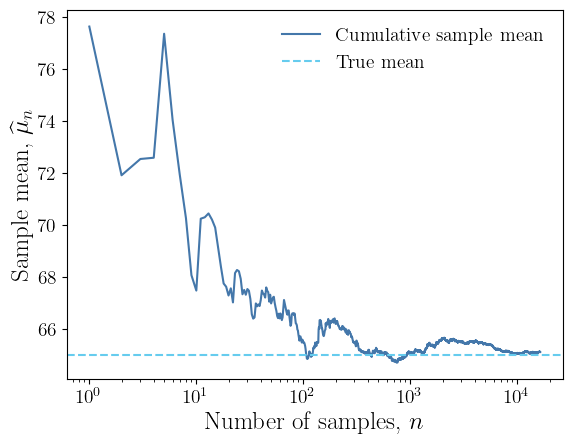

In [7]:
n_max = 2**14
nrange = np.arange(1, n_max + 1)
Wait_samples = WaitingTimeSampler(n_max)
T_samples = T0 + Wait_samples.sum(axis=1)
sample_mean_T = np.cumsum(T_samples) / nrange

plt.semilogx(nrange, sample_mean_T, label="Cumulative sample mean")
plt.axhline(true_mean_T, color=colors["cyan"], linestyle="--", label="True mean")
plt.xlabel(r"Number of samples, $n$")
plt.ylabel(r"Sample mean, $\widehat{\mu}_n$")
plt.legend(frameon=False);

<div class="highlight-note">
<h4>Notice that</h4>
<ul>
  <li>The sample mean approaches the true population mean</li>
  <li>The approach is oscillatory rather than monotone</li>
  <li>Running the cell again produces a different Monte Carlo path</li>
</ul>
</div>

## What is the convergence rate?

One Monte Carlo run shows what might happen, but a different random sample gives a different path. To study typical behavior, we repeat the entire experiment independently $R$ times:

$$
\widehat{\mu}_n^{(r)}
=\frac{1}{n}\sum_{i=1}^n T_i^{(r)},
\qquad r=1,\ldots,R.
$$

Each replication has its own absolute error $|\widehat{\mu}_n^{(r)}-\mu_T|$. The plot summarizes those $R$ observed errors: the line is their median and the band contains their middle 50%.

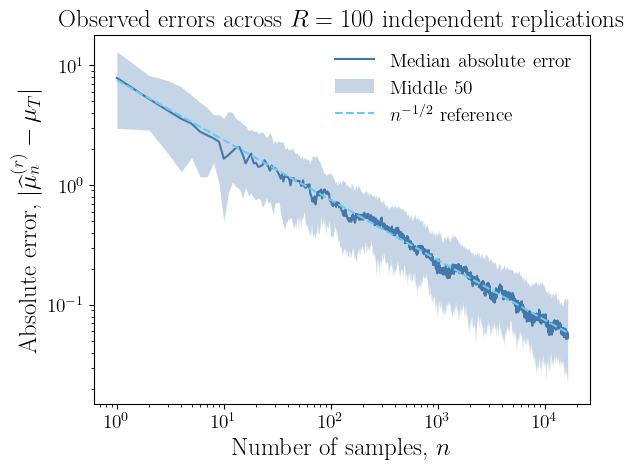

In [8]:
R = 100
IIDUniformSampler_R = qp.IIDStdUniform(dim, replications=R)

# Reuse the distributions defined above; only the underlying sampler changes.
WaitingTimeSampler_R = qp.ProductMeasure(
    sampler=IIDUniformSampler_R,
    marginals=[wait_L_marginal, wait_taxi_marginal],
)

Wait_samples_R = WaitingTimeSampler_R(n_max)
T_samples_R = T0 + Wait_samples_R.sum(axis=2)
sample_mean_T_R_reps = np.cumsum(T_samples_R, axis=1) / nrange
absolute_errors_T = np.abs(sample_mean_T_R_reps - true_mean_T)

bot_per, top_per = 25, 75
err_bot = np.percentile(absolute_errors_T, bot_per, axis=0)
err_med = np.percentile(absolute_errors_T, 50, axis=0)
err_top = np.percentile(absolute_errors_T, top_per, axis=0)

reference_index = 2**8 - 1
inverse_sqrt_reference = (
    err_med[reference_index]
    * (nrange / nrange[reference_index]) ** (-0.5)
)

fig, ax = plt.subplots()
ax.loglog(nrange, err_med, color=colors["blue"], label="Median absolute error")
ax.fill_between(
    nrange, err_bot, err_top, color=colors["blue"], alpha=0.3,
    linewidth=0, label="Middle 50% of absolute errors"
)
ax.loglog(
    nrange, inverse_sqrt_reference, "--", color=colors["cyan"],
    label=r"$n^{-1/2}$ reference"
)
ax.set_xlabel(r"Number of samples, $n$")
ax.set_ylabel(r"Absolute error, $|\widehat{\mu}_n^{(r)}-\mu_T|$")
ax.set_title(f"Observed errors across $R={R}$ independent replications")
ax.legend(frameon=False);

The shrinking band shows that the absolute error varies from replication to replication. Its overall scale follows $n^{-1/2}$: multiplying the sample size by four typically cuts the error roughly in half. This rate comes from averaging independent observations—the variance of an average is the variance of one observation divided by $n$.

### Root mean squared error when $\sigma_T$ is known

RMSE is not the absolute error from one replication. It is a population summary over hypothetical repetitions of the whole Monte Carlo experiment:

$$
\operatorname{RMSE}(\widehat{\mu}_n)
=\sqrt{\mathbb{E}\!\left[(\widehat{\mu}_n-\mu_T)^2\right]}.
$$

Because the sample mean is unbiased,

$$
\operatorname{RMSE}(\widehat{\mu}_n)
=\sqrt{\operatorname{Var}(\widehat{\mu}_n)}
=\frac{\sigma_T}{\sqrt{n}}.
$$

In this example the distribution is known, so $\sigma_T$ and the theoretical RMSE are known exactly. The empirical RMSE below replaces the expectation by an average over our $R$ replications. We also include the median absolute error on the same plot so that we can compare the two summaries directly.

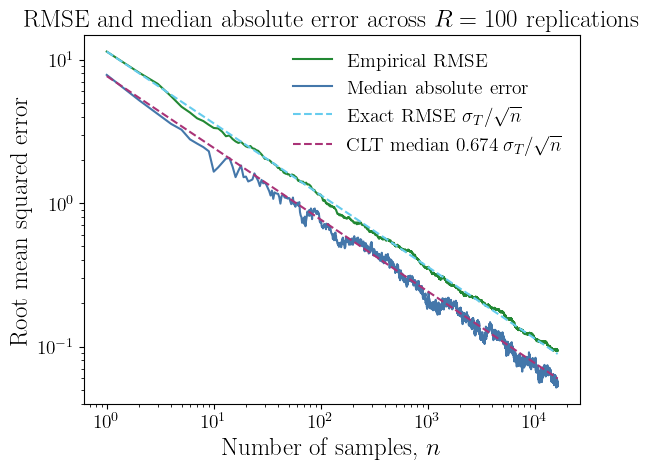

In [9]:
empirical_rmse_T = np.sqrt(np.mean((sample_mean_T_R_reps - true_mean_T)**2, axis=0))
theoretical_rmse_T = true_std_T / np.sqrt(nrange)
clt_median_absolute_error_T = stats.norm.ppf(0.75) * theoretical_rmse_T

fig, ax = plt.subplots()
ax.loglog(nrange, empirical_rmse_T, color=colors["green"], label="Empirical RMSE")
ax.loglog(
    nrange, err_med, color=colors["blue"],
    label="Median absolute error"
)
ax.loglog(
    nrange, theoretical_rmse_T, "--", color=colors["cyan"],
    label=r"Exact RMSE $\sigma_T/\sqrt{n}$"
)
ax.loglog(
    nrange, clt_median_absolute_error_T, "--", color=colors["purple"],
    label=r"CLT median $0.674\,\sigma_T/\sqrt{n}$"
)
ax.set_xlabel(r"Number of samples, $n$")
ax.set_ylabel("Root mean squared error")
ax.set_title(f"RMSE and median absolute error across $R={R}$ replications")
ax.legend(frameon=False);

### Why is the median absolute error below the RMSE?

The Central Limit Theorem (CLT) says that, for large $n$,

$$
\widehat{\mu}_n-\mu_T
\approx \frac{\sigma_T}{\sqrt{n}}Z,
\qquad Z\sim\mathcal{N}(0,1).
$$

Taking absolute values gives

$$
\operatorname{median}\!\left(|\widehat{\mu}_n-\mu_T|\right)
\approx \frac{\sigma_T}{\sqrt{n}}\operatorname{median}(|Z|).
$$

For a standard normal random variable, $\Pr(|Z|\le a)=2\Phi(a)-1$. Thus the $u$-quantile of $|Z|$ is $\Phi^{-1}((1+u)/2)$. In particular,

$$
\operatorname{median}(|Z|)=\Phi^{-1}(0.75)\approx 0.674.
$$

So the median absolute error is expected to be about $0.674\,\sigma_T/\sqrt{n}$, while the RMSE is $\sigma_T/\sqrt{n}$. They share the same $n^{-1/2}$ rate but have different constants. Similarly, the 25th and 75th percentiles of $|Z|$ use $\Phi^{-1}(0.625)$ and $\Phi^{-1}(0.875)$.

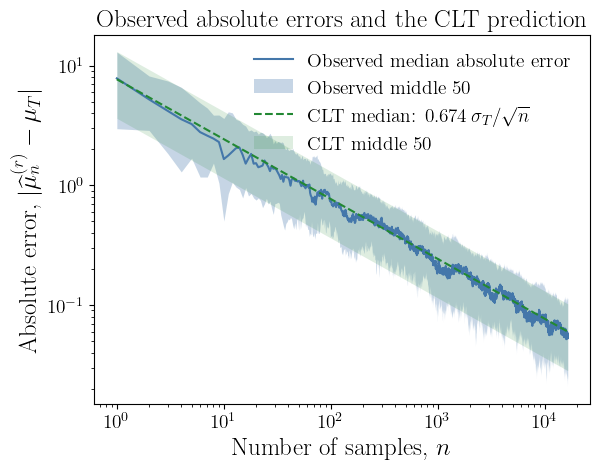

In [10]:
absolute_normal_quantiles = stats.norm.ppf((1 + np.array([0.25, 0.50, 0.75])) / 2)
clt_lower, clt_median, clt_upper = (
    absolute_normal_quantiles[:, None] * theoretical_rmse_T
)

fig, ax = plt.subplots()
ax.loglog(nrange, err_med, color=colors["blue"], label="Observed median absolute error")
ax.fill_between(
    nrange, err_bot, err_top, color=colors["blue"], alpha=0.3,
    linewidth=0, label="Observed middle 50%"
)
ax.loglog(
    nrange, clt_median, "--", color=colors["green"],
    label=r"CLT median: $0.674\,\sigma_T/\sqrt{n}$"
)
ax.fill_between(
    nrange, clt_lower, clt_upper, color=colors["green"], alpha=0.15,
    linewidth=0, label="CLT middle 50%"
)
ax.set_xlabel(r"Number of samples, $n$")
ax.set_ylabel(r"Absolute error, $|\widehat{\mu}_n^{(r)}-\mu_T|$")
ax.set_title("Observed absolute errors and the CLT prediction")
ax.legend(frameon=False);

## What if we do not know the standard deviation?

In a realistic simulation, we usually do not know $\sigma_T$. We then estimate it from data. Let $s_T$ denote the sample standard deviation from a pilot sample. Unlike the exact $\sigma_T$ above, $s_T$ is random and will change if the pilot experiment is repeated.

One simple workflow is to use an independent pilot sample to estimate the scale, then use a fresh sample to estimate the mean. A normal-approximation interval is

$$
\widehat{\mu}_n \;\pm\; z_{1-\alpha/2}\,\frac{s_T}{\sqrt{n}}.
$$

The optional inflation factor below is a practical cushion for uncertainty in $s_T$; it is not a proof of the advertised coverage probability.

In [11]:
confidence_level = 0.99
normal_quantile = stats.norm.ppf((1 + confidence_level) / 2)
pilot_sample_size = 100
mean_sample_size = 10_000
inflation_factor = 1.2

pilot_sampler, mean_sampler = WaitingTimeSampler.spawn(2)
pilot_wait_samples = pilot_sampler(pilot_sample_size)
pilot_travel_times = T0 + pilot_wait_samples.sum(axis=1)
estimated_std_T = np.std(pilot_travel_times, ddof=1)

mean_wait_samples = mean_sampler(mean_sample_size)
mean_travel_times = T0 + mean_wait_samples.sum(axis=1)
estimated_mean_T = np.mean(mean_travel_times)
estimated_half_width = (
    inflation_factor * normal_quantile * estimated_std_T / np.sqrt(mean_sample_size)
)
approximate_interval = estimated_mean_T + np.array([-1, 1]) * estimated_half_width

print(f"Exact population standard deviation: {true_std_T:.2f} minutes")
print(f"Pilot estimate of standard deviation: {estimated_std_T:.2f} minutes")
print(f"Monte Carlo estimate of the mean: {estimated_mean_T:.2f} minutes")
print(
    f"Inflated normal-approximation interval: "
    f"[{approximate_interval[0]:.2f}, {approximate_interval[1]:.2f}] minutes"
)

Exact population standard deviation: 11.37 minutes
Pilot estimate of standard deviation: 10.98 minutes
Monte Carlo estimate of the mean: 65.12 minutes
Inflated normal-approximation interval: [64.78, 65.46] minutes


Here the pilot estimate $s_T$ is the quantity we would have in a realistic problem. The exact value $\sigma_T$ is printed only as a benchmark. The interval describes uncertainty in the Monte Carlo estimate of $\mu_T$; it does not describe the spread of individual trip times.

## What does “plan for the trip to take” mean?

We can now return to the question at the beginning. There is no single numerical answer until we decide what *plan* means.

| Interpretation | Quantity | What it tells us |
|---|---:|---|
| A typical long-run amount | Mean $\mu_T$ | The average duration over many trips |
| A typical individual trip | Median $q_{0.5}$ | Half of trips finish by this time and half take longer |
| A deadline with a chosen reliability | High quantile $q_p$ | A proportion $p$ of trips finish by this time |
| Precision of our Monte Carlo mean | Confidence interval for $\mu_T$ | How uncertain our numerical estimate of the mean is |

These answers serve different purposes. The mean is about 65 minutes, but it does **not** imply a 50%, 90%, or 99% chance of arriving within 65 minutes. The median directly describes a typical individual trip. A high quantile is usually the most useful answer when arriving late has a consequence.

The confidence interval above is different in kind. It describes Monte Carlo uncertainty about the mean $\mu_T$; it is not an interval containing a stated percentage of individual travel times. In particular, a 99% confidence interval for the mean should not be interpreted as saying that 99% of trips fall inside that narrow interval.

For this tractable model, we can also compute the true median from the distribution and compare it with the simulated medians.

In [12]:
from scipy.optimize import brentq

def random_wait_cdf(wait_time):
    """CDF of W1 + W2 for the current travel-time model."""
    rate = 1 / taxi_wait_avg
    if wait_time < 0:
        return 0.0
    if wait_time <= max_L_time:
        return (
            wait_time / max_L_time
            - (1 - taxi_now) / (rate * max_L_time)
            * (1 - np.exp(-rate * wait_time))
        )
    return 1 - (
        (1 - taxi_now) * np.exp(-rate * wait_time)
        * np.expm1(rate * max_L_time) / (rate * max_L_time)
    )

true_median_T = T0 + brentq(
    lambda wait_time: random_wait_cdf(wait_time) - 0.5,
    0,
    10 * taxi_wait_avg + max_L_time,
)

replicated_median_estimates = np.median(T_samples_R, axis=1)
median_estimate_middle_half = np.percentile(
    replicated_median_estimates, [25, 75]
)

print(f"True mean: {true_mean_T:.2f} minutes")
print(f"True median: {true_median_T:.2f} minutes")
print(
    f"Median of the {R} Monte Carlo median estimates: "
    f"{np.median(replicated_median_estimates):.2f} minutes"
)
print(
    f"Middle 50% of those estimates: "
    f"[{median_estimate_middle_half[0]:.2f}, "
    f"{median_estimate_middle_half[1]:.2f}] minutes"
)

True mean: 65.00 minutes
True median: 63.46 minutes
Median of the 100 Monte Carlo median estimates: 63.45 minutes
Middle 50% of those estimates: [63.37, 63.51] minutes


## How much travel time should I allow?

The median is the 50th percentile. If being late matters, we may instead want approximately a 90% chance of arriving by the planned time. This asks for the 90th percentile, not the mean. The $p$-quantile is defined by

$$
q_p=\inf\{t:\Pr(T\le t)\ge p\}.
$$

For a continuous distribution this reduces to $\Pr(T\le q_p)=p$. Estimating a quantile is a different Monte Carlo task: we sort the simulated travel times and locate the desired percentile rather than average them.

Because we already have $R$ independent replications, we can see both how the estimated 90th percentile converges toward the true quantile and how its sampling variability decreases as the sample size increases.

Exact 90th percentile: 79.41 minutes
At n=16,384, the median Monte Carlo estimate is 79.43 minutes.


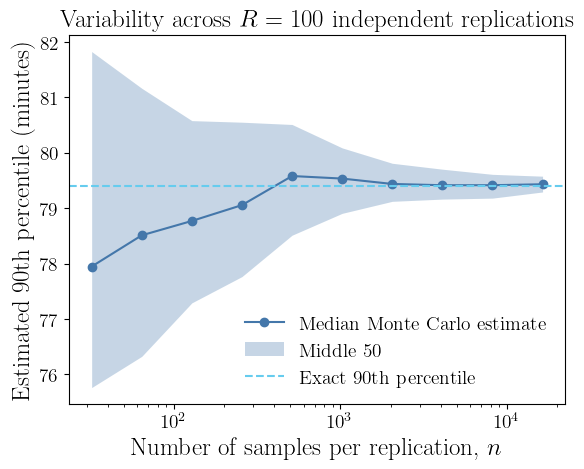

In [13]:
prob = 0.90
quantile_sample_sizes = 2 ** np.arange(5, 15)
quantile_estimates = np.array([
    np.quantile(T_samples_R[:, :sample_size], prob, axis=1)
    for sample_size in quantile_sample_sizes
])

quantile_lower = np.percentile(quantile_estimates, 25, axis=1)
quantile_median = np.percentile(quantile_estimates, 50, axis=1)
quantile_upper = np.percentile(quantile_estimates, 75, axis=1)

# For this model q_0.9 lies above T0 + max_L_time, where the exact tail
# probability of W1 + W2 has a simple exponential form.
tail_probability = 1 - prob
quantile_random_part = -np.log(
    tail_probability * (1 / taxi_wait_avg) * max_L_time
    / ((1 - taxi_now) * np.expm1(max_L_time / taxi_wait_avg))
) * taxi_wait_avg
true_quantile_90 = T0 + quantile_random_part

fig, ax = plt.subplots()
ax.semilogx(
    quantile_sample_sizes, quantile_median, marker="o", color=colors["blue"],
    label="Median Monte Carlo estimate"
)
ax.fill_between(
    quantile_sample_sizes, quantile_lower, quantile_upper,
    color=colors["blue"], alpha=0.3, linewidth=0,
    label="Middle 50% of estimates"
)
ax.axhline(
    true_quantile_90, color=colors["cyan"], linestyle="--",
    label="Exact 90th percentile"
)
ax.set_xlabel(r"Number of samples per replication, $n$")
ax.set_ylabel("Estimated 90th percentile (minutes)")
ax.set_title(f"Variability across $R={R}$ independent replications")
ax.legend(frameon=False);

final_quantile_estimates = quantile_estimates[-1]
print(f"Exact 90th percentile: {true_quantile_90:.2f} minutes")
print(
    f"At n={n_max:,}, the median Monte Carlo estimate is "
    f"{np.median(final_quantile_estimates):.2f} minutes."
)

Because this model is tractable, the exact 90th percentile gives us a benchmark for the Monte Carlo estimates. In more complicated models the simulation procedure is the same, even when no exact answer is available.

<div class="highlight-note">
Allow about <strong>80 minutes</strong> of travel time if you want approximately a 90% chance of arriving by then. The exact model benchmark is about 79.4 minutes, so rounding up to 80 minutes is a practical interpretation.
</div>

So far we have changed the sample size but not the basic simulation method. The next two sections preview ways to use either more information about the model or more evenly distributed sample points.

## Conditional Monte Carlo

Ordinary Monte Carlo treats each simulated travel time as a black-box output. If we can analyze part of the model, conditional Monte Carlo replaces some simulation by an exact conditional calculation.

Here, once $W_2$ is fixed, the remaining randomness comes only from the uniform train wait $W_1$. Therefore we can replace $T$ by its conditional mean given $W_2$. This removes the variability due to $W_1$ while preserving the mean we want to estimate.

In [14]:
display(Markdown(fr"""
\begin{{align*}}
T &= {T0} + W_1 + W_2, \\
W_1 &\sim \mathcal{{U}}[0,{max_L_time}], \\
g(W_2)
    := \mathbb{{E}}[T \mid W_2]
    &= {T0 + max_L_time / 2:.0f} + W_2, \\
\mathbb{{E}}[g(W_2)] &= \mathbb{{E}}[T].
\end{{align*}}

For density estimation, the same conditioning identity gives

\begin{{align*}}
f_T(t)
&= \mathbb{{E}}\!\left[f_{{T\mid W_2}}(t\mid W_2)\right] \\
&= \frac{{1}}{{{max_L_time}}}
   \mathbb{{E}}\!\left[
   \mathbb{{1}}_{{[t-{T0 + max_L_time},\,t-{T0}]}}(W_2)
   \right].
\end{{align*}}
"""))


\begin{align*}
T &= 47 + W_1 + W_2, \\
W_1 &\sim \mathcal{U}[0,20], \\
g(W_2)
    := \mathbb{E}[T \mid W_2]
    &= 57 + W_2, \\
\mathbb{E}[g(W_2)] &= \mathbb{E}[T].
\end{align*}

For density estimation, the same conditioning identity gives

\begin{align*}
f_T(t)
&= \mathbb{E}\!\left[f_{T\mid W_2}(t\mid W_2)\right] \\
&= \frac{1}{20}
   \mathbb{E}\!\left[
   \mathbb{1}_{[t-67,\,t-47]}(W_2)
   \right].
\end{align*}


We first compare estimation of $\mathbb{E}[T]$ using the original travel times $T$ with estimation using the conditional values $g(W_2)=\mathbb{E}[T\mid W_2]$. Both estimators are unbiased for the same exact mean $\mu_T$.

Exact standard deviation of $T$: 11.37 minutes
Exact standard deviation of $g(W_2)$: 9.80 minutes


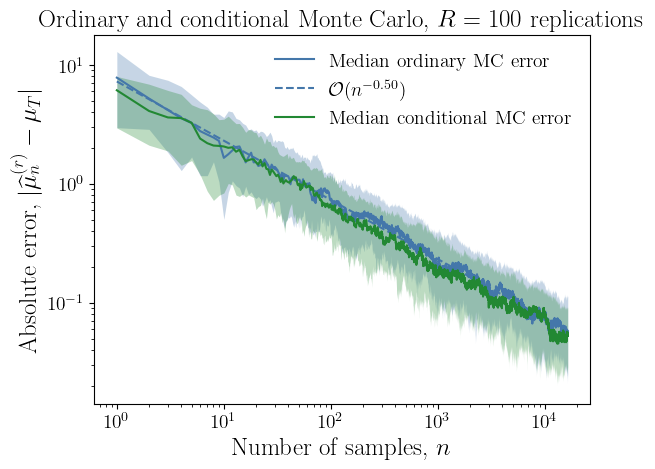

In [15]:
W2_R_samples = Wait_samples_R[:, :, 1]
cond_T_R_reps = T0 + max_L_time/2 + W2_R_samples  #replicated samples of conditional expectation of T given W_2 = w2
print(f"Exact standard deviation of $T$: {true_std_T:.2f} minutes\n" \
      f"Exact standard deviation of $g(W_2)$: {W2_std:.2f} minutes")
sample_mean_cond_T_R_reps = np.cumsum(cond_T_R_reps, axis=1) / nrange  #compute the sample mean
err_sample_mean_cond_T_R_reps = np.abs(true_mean_T - sample_mean_cond_T_R_reps)  #errors
err_bot_cond = np.percentile(err_sample_mean_cond_T_R_reps, bot_per, axis=0)
err_med_cond = np.percentile(err_sample_mean_cond_T_R_reps, 50, axis=0)
err_top_cond = np.percentile(err_sample_mean_cond_T_R_reps, top_per, axis=0)
fig, ax = plt.subplots()
ax.loglog(nrange,err_med, '-', color = colors["blue"], label="Median ordinary MC error")
ax.fill_between(nrange, err_bot, err_top, color = colors["blue"],alpha = 0.3, linewidth = 0)
cl.nbviz.plot_log_trend_line(ax,nrange,err_med,color=colors["blue"])
ax.loglog(nrange,err_med_cond, '-', color = colors["green"], label="Median conditional MC error")
ax.fill_between(nrange, err_bot_cond, err_top_cond, color = colors["green"],alpha = 0.3, linewidth = 0)
ax.set_xlabel(r"Number of samples, $n$")
ax.set_ylabel(r"Absolute error, $|\widehat{\mu}^{(r)}_n-\mu_T|$")
ax.set_title(f"Ordinary and conditional Monte Carlo, $R={R}$ replications")
plt.legend(frameon=False);

Both methods retain the ordinary Monte Carlo rate $n^{-1/2}$. Conditioning reduces the standard deviation from about $11.37$ minutes to $9.80$ minutes, so the error is somewhat smaller but the improvement is modest in this example. The important idea is that analytically averaging over $W_1$ removes one source of sampling variability.

### Estimating the travel-time density

A histogram or kernel density estimate uses the simulated travel times directly. Conditional Monte Carlo instead averages the exact conditional density $f_{T\mid W_2}(t\mid W_2)$ over sampled taxi waits. This replaces each simulated travel time by an entire uniform density and can produce a much less variable estimate of $f_T(t)$.

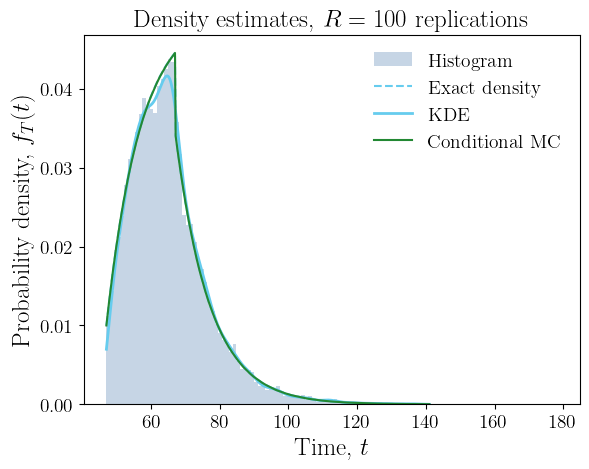

In [16]:
#This is conditional Monte Carlo to estimate the density
Tplot = np.linspace(T0, 3*T0, 500)
Tplot_min_T0 = Tplot.reshape(1,1,-1) - T0
sample_mean_rho_T_R_reps = np.mean((W2_R_samples[:, :, None] >= Tplot_min_T0 - max_L_time) & \
                                   (W2_R_samples[:, :, None] <= Tplot_min_T0), axis=1)/max_L_time 
rho_bot_cond = np.percentile(sample_mean_rho_T_R_reps, bot_per, axis=0)
rho_med_cond = np.percentile(sample_mean_rho_T_R_reps, 50, axis=0)
rho_top_cond = np.percentile(sample_mean_rho_T_R_reps, top_per, axis=0)

# Exact density, available here as a benchmark
random_wait_plot = Tplot - T0
rate = 1 / taxi_wait_avg
exact_density_T = np.zeros_like(Tplot)
before_max_train_wait = (random_wait_plot >= 0) & (random_wait_plot < max_L_time)
after_max_train_wait = random_wait_plot >= max_L_time
exact_density_T[before_max_train_wait] = (
    1 - (1 - taxi_now) * np.exp(-rate * random_wait_plot[before_max_train_wait])
) / max_L_time
exact_density_T[after_max_train_wait] = (1 - taxi_now) * (
    np.exp(-rate * (random_wait_plot[after_max_train_wait] - max_L_time))
    - np.exp(-rate * random_wait_plot[after_max_train_wait])
) / max_L_time

# Kernel density estimator based on the simulated travel times
rho_kde = stats.gaussian_kde(T_samples)
rho_kde_plot = rho_kde(Tplot)

#Now we plot these plus the histogram
fig, ax = plt.subplots()
ax.hist(T_samples, bins="auto", density=True, alpha=0.3, label="Histogram")  #histogram to estimate the probability density
ax.plot(Tplot, exact_density_T, '--', color=colors["cyan"], label="Exact density")
ax.plot(Tplot, rho_kde_plot, label="KDE", linewidth=2)
ax.plot(Tplot,rho_med_cond, '-', color = colors["green"], label="Conditional MC")
ax.fill_between(Tplot, rho_bot_cond, rho_top_cond, color = colors["green"],alpha = 0.3, linewidth = 0)
ax.set_xlabel(r"Time, $t$")
ax.set_ylabel(r"Probability density, $f_T(t)$")
ax.set_title(f"Density estimates, $R={R}$ replications")
plt.legend(frameon=False);

<div class="highlight-note">
<h4>What should we notice?</h4>
<ul>
  <li>The histogram is a rough, bin-dependent density estimate from one simulated sample.</li>
  <li>The kernel density estimate is smoother, but smoothing blurs features of the exact density.</li>
  <li>The conditional Monte Carlo estimates concentrate tightly around the exact density; their middle 50% band is barely visible.</li>
</ul>
</div>

## Low discrepancy sampling

The calculations above use IID points. Low discrepancy (LD) methods instead place points more evenly throughout the unit square, reducing the gaps and clusters typical of IID sampling. QMCPy's randomized Sobol sampler provides $R$ independent randomizations; within each replication, however, the points are deliberately coordinated rather than IID.

The marginal quantile functions transform these Sobol points into train and taxi waits. The estimator is still an average of simulated travel times, but the sampling design has changed. For many sufficiently regular problems this can reduce error, although the improvement is problem-dependent. This example previews ideas we will study later.

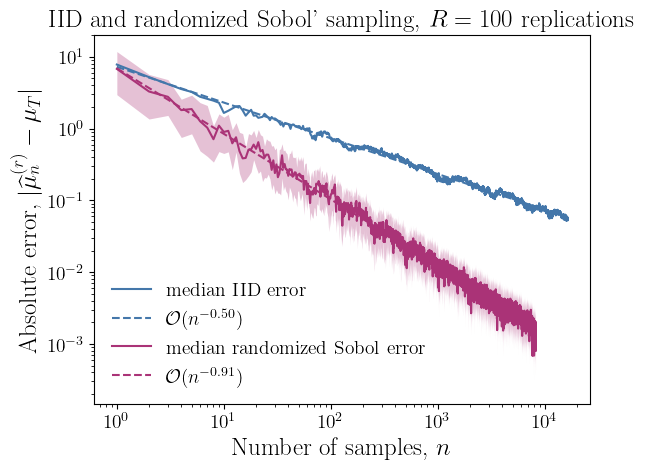

In [17]:
n_LD_max = 2**13  #must be a power of 2
n_LD_range = np.arange(1, n_LD_max+1)
WaitingTimeSampler_LD_R = qp.ProductMeasure(
    sampler=qp.Sobol(dimension=2, replications=R),
    marginals=[wait_L_marginal, wait_taxi_marginal],
)
Wait_LD_R_samples = WaitingTimeSampler_LD_R(n_LD_max)
W1_LD_R_samples = Wait_LD_R_samples[:, :, 0]
W2_LD_R_samples = Wait_LD_R_samples[:, :, 1]
T_LD_R_samples = T0 + Wait_LD_R_samples.sum(axis=2)  #generate R replications of travel-time samples
sample_mean_T_LD_R_reps = np.cumsum(T_LD_R_samples, axis = 1) / n_LD_range   #compute the travel time sample means for all N replications
error_sample_mean_T_LD = np.abs(true_mean_T - sample_mean_T_LD_R_reps)  #errors
err_LD_bot = np.percentile(error_sample_mean_T_LD, bot_per, axis=0)
err_LD_med = np.percentile(error_sample_mean_T_LD, 50, axis=0)
err_LD_top = np.percentile(error_sample_mean_T_LD, top_per, axis=0)
fig, ax = plt.subplots()
ax.loglog(nrange,err_med, '-', color = colors["blue"], label="median IID error")
cl.nbviz.plot_log_trend_line(ax,nrange,err_med,color=colors["blue"])
ax.loglog(n_LD_range,err_LD_med, '-', color = colors["purple"], label="median randomized Sobol error")
cl.nbviz.plot_log_trend_line(ax,n_LD_range,err_LD_med,color=colors["purple"])
ax.fill_between(n_LD_range, err_LD_bot, err_LD_top, color = colors["purple"],alpha = 0.3, linewidth = 0)
ax.set_xlabel(r"Number of samples, $n$")
ax.set_ylabel(r"Absolute error, $|\widehat{\mu}^{(r)}_n-\mu_T|$")
ax.set_title(f"IID and randomized Sobol' sampling, $R={R}$ replications")
plt.legend(frameon=False);

For this example, the median error from randomized Sobol sampling is lower and decreases more rapidly than the median IID error over the sample sizes shown. This empirical comparison is encouraging, not a universal convergence guarantee.

The point plots below give some intuition: the Sobol points leave fewer large gaps and form fewer clusters than the IID points.

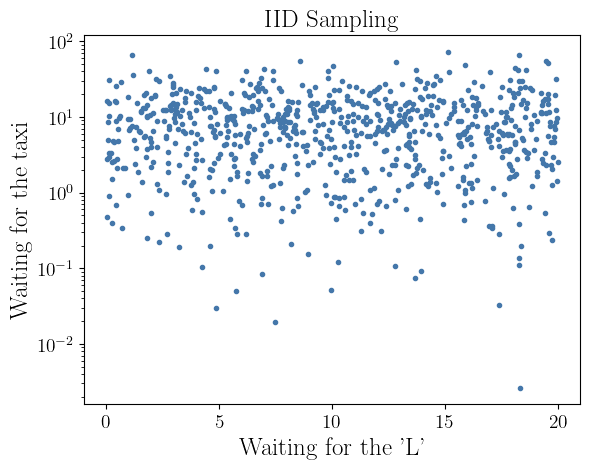

In [18]:
#First the IID sampling
plt.semilogy(Wait_samples[:1000, 0], Wait_samples[:1000, 1],'.')
plt.xlabel("Waiting for the 'L'")
plt.ylabel("Waiting for the taxi")
plt.title("IID Sampling");

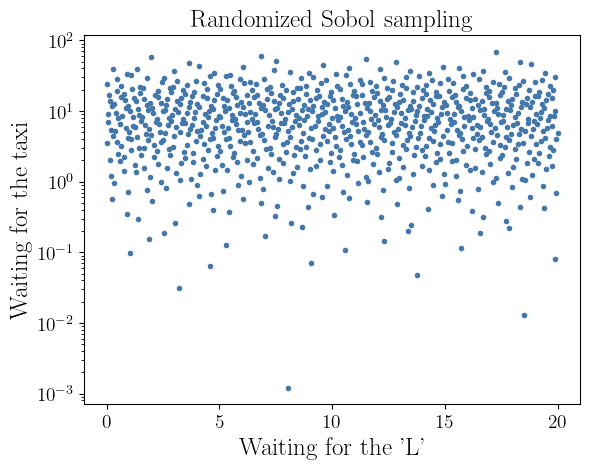

In [19]:
#Next the LD sampling
plt.semilogy(W1_LD_R_samples[0,:1000],W2_LD_R_samples[0,:1000],'.')
plt.xlabel("Waiting for the 'L'")
plt.ylabel("Waiting for the taxi")
plt.title("Randomized Sobol sampling");

<div class="highlight-note">
<h4>Three versions of the same estimation problem</h4>
<ul>
  <li><strong>Ordinary Monte Carlo:</strong> simulate every random input independently.</li>
  <li><strong>Conditional Monte Carlo:</strong> analytically average over part of the randomness before sampling.</li>
  <li><strong>Randomized Sobol sampling:</strong> use more evenly distributed sample points instead of IID points.</li>
</ul>
</div>

All three methods target the same population quantities. Because this travel-time model has exact answers, we can see what each method changes and compare its estimates with truth. Later in the course we will return to conditional Monte Carlo and low discrepancy sampling for problems where those improvements matter more—and where exact answers are unavailable.